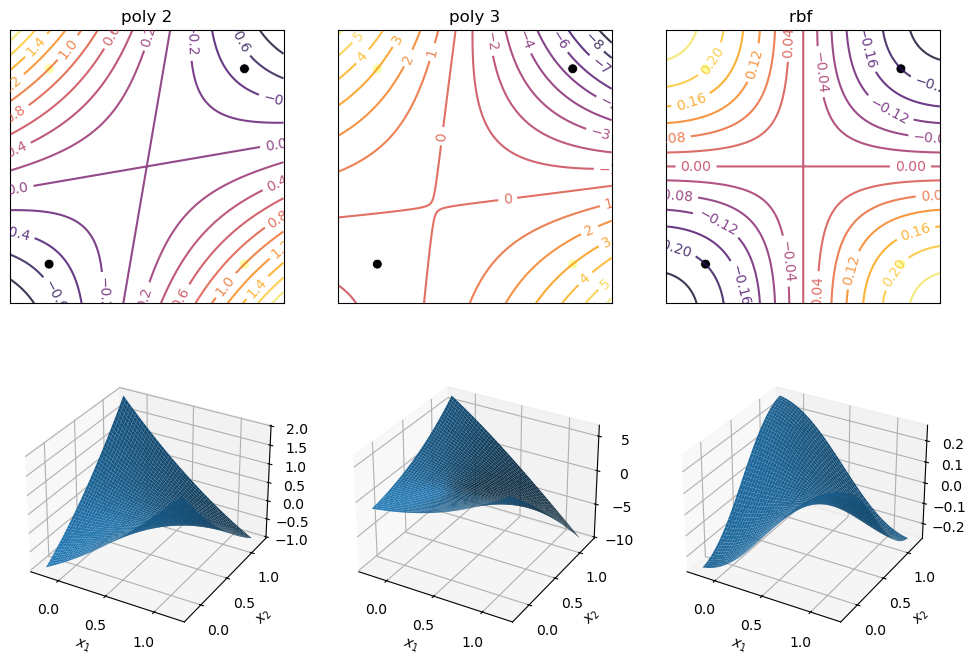

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as st


class KPerceptron(object):

    def __init__(self, ker='poly', gamma=1, coef0=1, degree=2, eta0=1.0, max_iter=100):
        self.ker = getattr(self, ker)
        self.gamma, self.coef0, self.degree = gamma, coef0, degree
        self.eta0, self.max_iter = eta0, max_iter

    def linear(self, Z):  # (|Z|,|SV|), linear = <Z,sv>
        sv = self.sv[self.sv_index]
        return np.dot(Z, sv.T)

    def poly(self, Z):  # (|Z|,|SV|), poly = (γ <Z,sv> + c)^d
        return (self.gamma * self.linear(Z) + self.coef0)**self.degree

    def rbf(self, Z):  # (|Z|,|SV|), rbf = exp(- γ |Z-sv|^2)
        sv = self.sv[self.sv_index]
        sv_norm = (sv**2).sum(axis=1)  # (|SV|,)
        if Z.ndim == 1:
            Z_norm = (Z[:, np.newaxis]**2).sum(axis=0)  # (|Z|,)
        else:
            Z_norm = (Z**2).sum(axis=1)  # (|Z|,)
        return np.exp(-self.gamma * (Z_norm.reshape((-1, 1)) - 2 * self.linear(Z) + sv_norm))  # 用到了广播机制

    def decision_function(self, Z):  # 对Z的预测值
        return np.dot(self.ker(Z), self.alpha[self.sv_index])

    def fit(self, X, y, classes=None):
        m = X.shape[0]  # 样本数
        for k in range(self.max_iter):
            if not hasattr(self, 'sv'):
                self.alpha = np.zeros(m)
                self.sv_index = np.zeros(m, dtype=bool)
                self.sv = X
            indexes = np.random.permutation(m)  # 随机打乱样本顺序
            stop = True
            for i in np.arange(0, m):
                xi, yi = X[indexes[i], :], y[indexes[i]]
                if yi * self.decision_function(xi) <= 0:  # 预测错误 更新模型
                    self.alpha[indexes[i]] = self.alpha[indexes[i]] + yi * self.eta0
                    stop = False
                if self.alpha[indexes[i]] != 0:
                    self.sv_index[indexes[i]] = True
                else:
                    self.sv_index[indexes[i]] = False
            if stop:
                # print('模型在第%d轮训练完毕' % (i+1))
                return

        # print('达到最大迭代轮数')

    def predict(self, Z):
        return np.sign(self.decision_function(Z))

    def score(self, Z, y):
        return np.sum(self.predict(Z) == y) / float(y.size)


def grid(func, *args):  # 计算格点上的函数值 用于后续画等高线或热力图
    x_min, x_max, y_min, y_max = args
    grid_x, grid_y = np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000))
    grid_z = func(np.column_stack((grid_x.ravel(), grid_y.ravel())))
    grid_z = grid_z.reshape(grid_x.shape)
    return grid_x, grid_y, grid_z


np.random.seed(1)

X = np.array([[1, 1], [1, 0], [0, 1], [0, 0]])
y = np.array([-1, 1, 1, -1])
conf = [['poly', 2], ['poly', 3], ['rbf', '']]
figure = plt.figure(figsize=(8 * len(conf) / 2, 8))
x_min, x_max, y_min, y_max = -0.2, 1.2, -0.2, 1.2

for i, (ker, param) in enumerate(conf):

    kp = KPerceptron(ker=ker, gamma=1, coef0=1, degree=param, eta0=0.5)
    kp.fit(X, y)
    acc = kp.score(X, y)
    grid_x, grid_y, grid_z = grid(kp.decision_function, x_min, x_max, y_min, y_max)

    ax = plt.subplot(2, len(conf), i + 1)
    ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max), xticks=(), yticks=(), aspect="equal", title=f"{ker} {param}")
    contours = ax.contour(grid_x, grid_y, grid_z, 16, alpha=.8, cmap='inferno')
    ax.clabel(contours)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], s=50, hue=y, palette='inferno', legend=False, ax=ax)

    ax = plt.subplot(2, len(conf), i + len(conf) + 1, projection='3d')
    ax.plot_surface(grid_x, grid_y, grid_z)
    ax.set(xlabel="$x_1$", ylabel="$x_2$")

plt.show()